# Corpus Normalisation

Media coverage of individual MPs is highly uneven; a small number of prominent figures (e.g. party leaders, Prime Ministers) dominate the corpus. Without correction, framing profiles would disproportionately reflect the portrayal of these individuals rather than gendered patterns more broadly.

This notebook:
1. Visualises per-MP sentence frequency distributions — **by topic** and **in aggregate**
2. Applies a regularisation procedure: for each MP, a random subsample is drawn so no individual contributes more than a fixed cap
3. Compares before/after distributions to confirm the skew has been mitigated
4. Exports the normalised dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import os

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

SEED = 42
np.random.seed(SEED)

## 1. Load all topic files

In [2]:
DATA_DIR = Path("../coreference/mp_sentences_by_topic")

topic_files = sorted(DATA_DIR.glob("*.csv"))
print(f"Found {len(topic_files)} topic files:\n")

# Load each topic into a dict and concatenate
topic_dfs = {}
for f in topic_files:
    topic_name = f.stem  # e.g. "0_covid_virus_vaccine_pandemic"
    df = pd.read_csv(f)
    topic_dfs[topic_name] = df
    print(f"  {topic_name}: {len(df):,} sentences, {df['mp'].nunique()} unique MPs")

# Combined aggregate dataframe
df_all = pd.concat(topic_dfs.values(), ignore_index=True)
print(f"\nAggregate: {len(df_all):,} sentences, {df_all['mp'].nunique()} unique MPs")
print(f"Gender split: {df_all['gender'].value_counts().to_dict()}")

Found 10 topic files:

  0_covid_virus_vaccine_pandemic: 1,777 sentences, 112 unique MPs
  1_climate_emissions_carbon_energy: 965 sentences, 115 unique MPs
  2_scottish_scotland_snp_sturgeon: 3,233 sentences, 180 unique MPs
  3_biden_trump_sanders_democratic: 51 sentences, 15 unique MPs
  4_schools_school_education_teachers: 739 sentences, 89 unique MPs
  5_farage_ukip_nuttall_party: 2,470 sentences, 151 unique MPs
  6_her_she_may_brexit: 2,940 sentences, 179 unique MPs
  7_book_books_novel_my: 73 sentences, 25 unique MPs
  8_nhs_health_doctors_patients: 1,021 sentences, 91 unique MPs
  9_eu_barnier_uk_deal: 1,473 sentences, 114 unique MPs

Aggregate: 14,742 sentences, 497 unique MPs
Gender split: {'M': 11452, 'F': 3290}


## 2. Aggregate distributions (before normalisation)

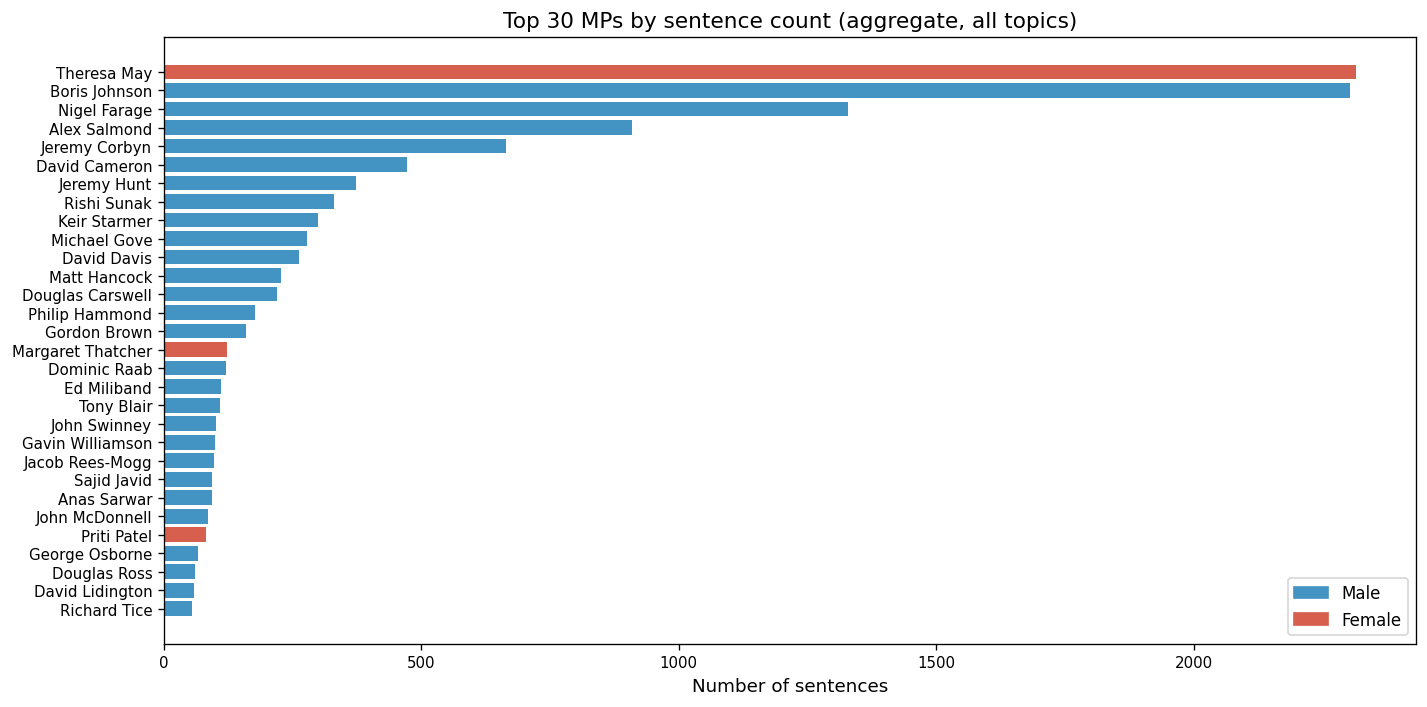

In [3]:
# --- Aggregate: top 30 MPs by sentence count ---
mp_counts = df_all.groupby(["mp", "gender"]).size().reset_index(name="count")
mp_counts = mp_counts.sort_values("count", ascending=False)

top_n = 30
top_mps = mp_counts.head(top_n)

colours = top_mps["gender"].map({"M": "#4393c3", "F": "#d6604d"})

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(top_n), top_mps["count"].values, color=colours.values)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_mps["mp"].values)
ax.invert_yaxis()
ax.set_xlabel("Number of sentences")
ax.set_title(f"Top {top_n} MPs by sentence count (aggregate, all topics)")

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#4393c3", label="Male"),
                   Patch(color="#d6604d", label="Female")],
          loc="lower right")
plt.tight_layout()
plt.show()

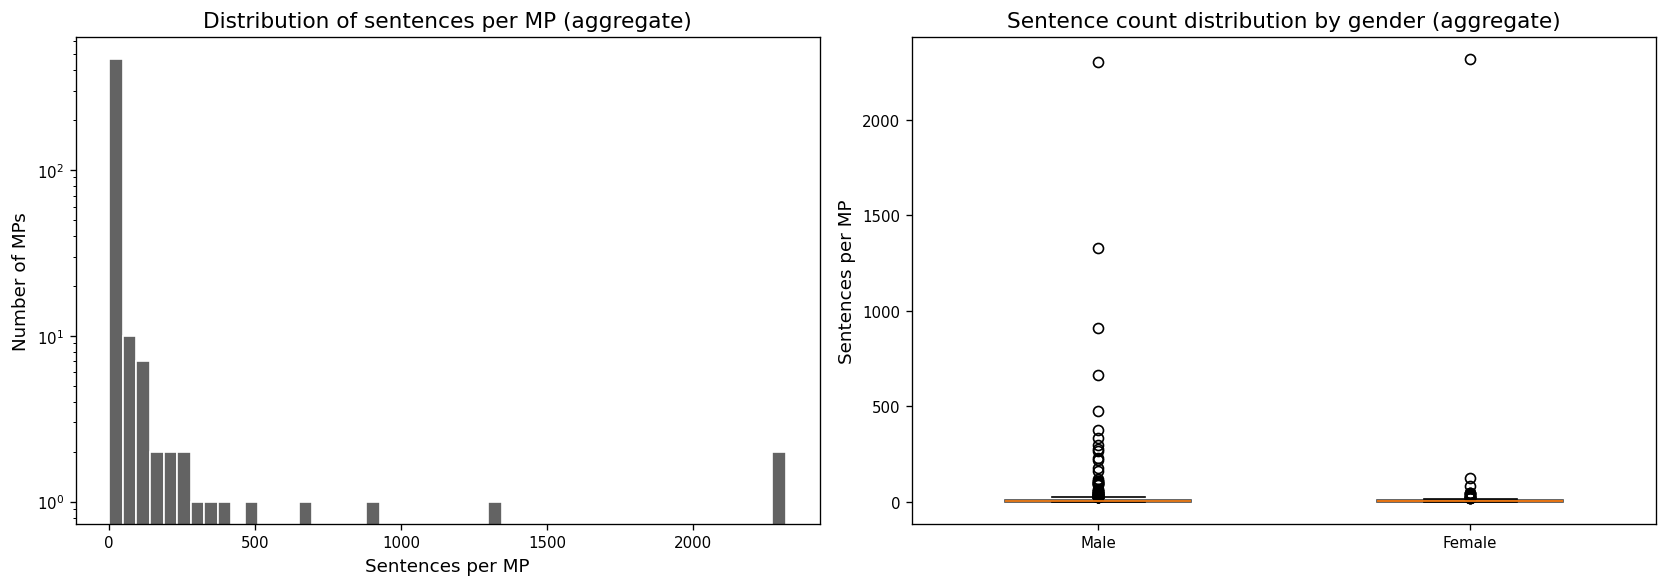

Per-MP sentence count statistics (aggregate):
count     497.000000
mean       29.661972
std       169.922463
min         1.000000
25%         1.000000
50%         3.000000
75%        10.000000
max      2316.000000

Gini-like concentration: top 10 MPs account for 62.9% of all sentences


In [4]:
# --- Aggregate: histogram of per-MP sentence counts ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram
axes[0].hist(mp_counts["count"], bins=50, color="#636363", edgecolor="white")
axes[0].set_xlabel("Sentences per MP")
axes[0].set_ylabel("Number of MPs")
axes[0].set_title("Distribution of sentences per MP (aggregate)")
axes[0].set_yscale("log")

# Box plot by gender
for i, (g, colour) in enumerate([("M", "#4393c3"), ("F", "#d6604d")]):
    data = mp_counts.loc[mp_counts["gender"] == g, "count"]
    bp = axes[1].boxplot(data, positions=[i], widths=0.5, patch_artist=True,
                         boxprops=dict(facecolor=colour, alpha=0.7))
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Male", "Female"])
axes[1].set_ylabel("Sentences per MP")
axes[1].set_title("Sentence count distribution by gender (aggregate)")

plt.tight_layout()
plt.show()

# Summary statistics
print("Per-MP sentence count statistics (aggregate):")
print(mp_counts["count"].describe().to_string())
print(f"\nGini-like concentration: top 10 MPs account for "
      f"{mp_counts.head(10)['count'].sum() / mp_counts['count'].sum():.1%} of all sentences")

## 3. Per-topic distributions (before normalisation)

Top 15 MPs in each topic, plus per-topic gender breakdown.

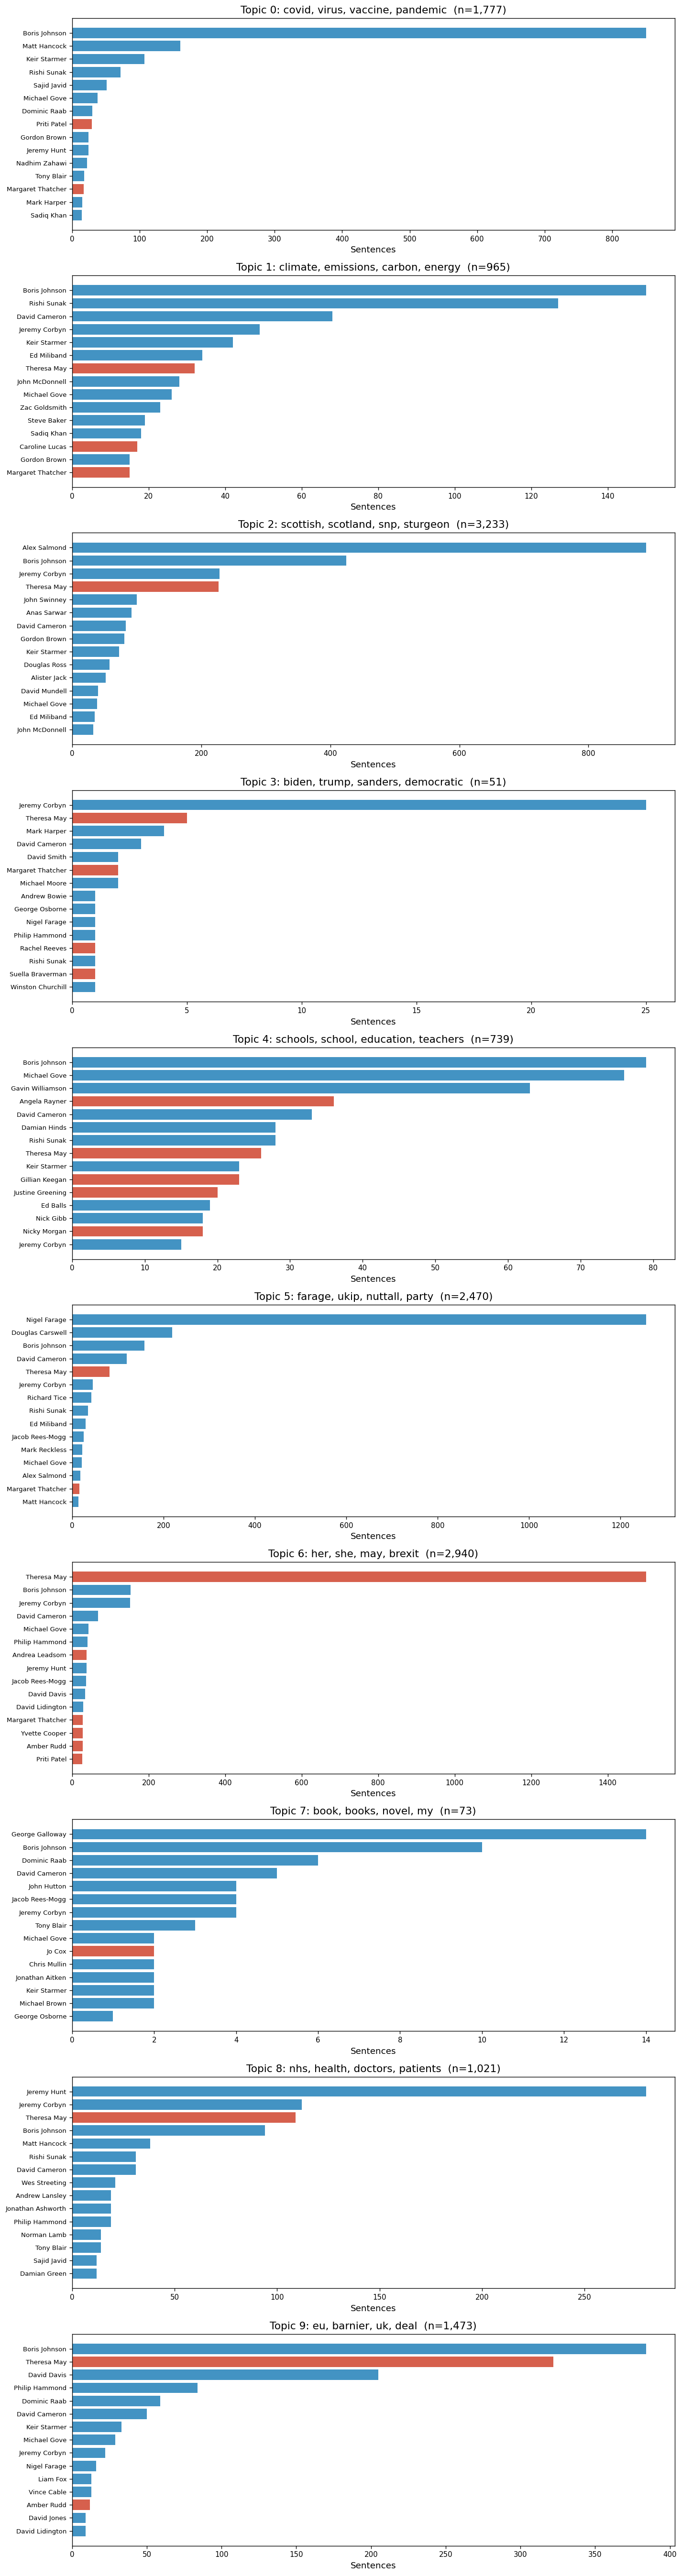

In [5]:
# --- Per-topic: top 15 MPs ---
n_topics = len(topic_dfs)
fig, axes = plt.subplots(n_topics, 1, figsize=(12, 4.5 * n_topics))

for idx, (topic_name, tdf) in enumerate(sorted(topic_dfs.items())):
    ax = axes[idx]
    tc = tdf.groupby(["mp", "gender"]).size().reset_index(name="count")
    tc = tc.sort_values("count", ascending=False).head(15)

    colours = tc["gender"].map({"M": "#4393c3", "F": "#d6604d"})
    ax.barh(range(len(tc)), tc["count"].values, color=colours.values)
    ax.set_yticks(range(len(tc)))
    ax.set_yticklabels(tc["mp"].values, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Sentences")

    # Pretty topic label
    label = topic_name.split("_", 1)[1].replace("_", ", ")
    ax.set_title(f"Topic {topic_name[0]}: {label}  (n={len(tdf):,})")

plt.tight_layout()
plt.show()

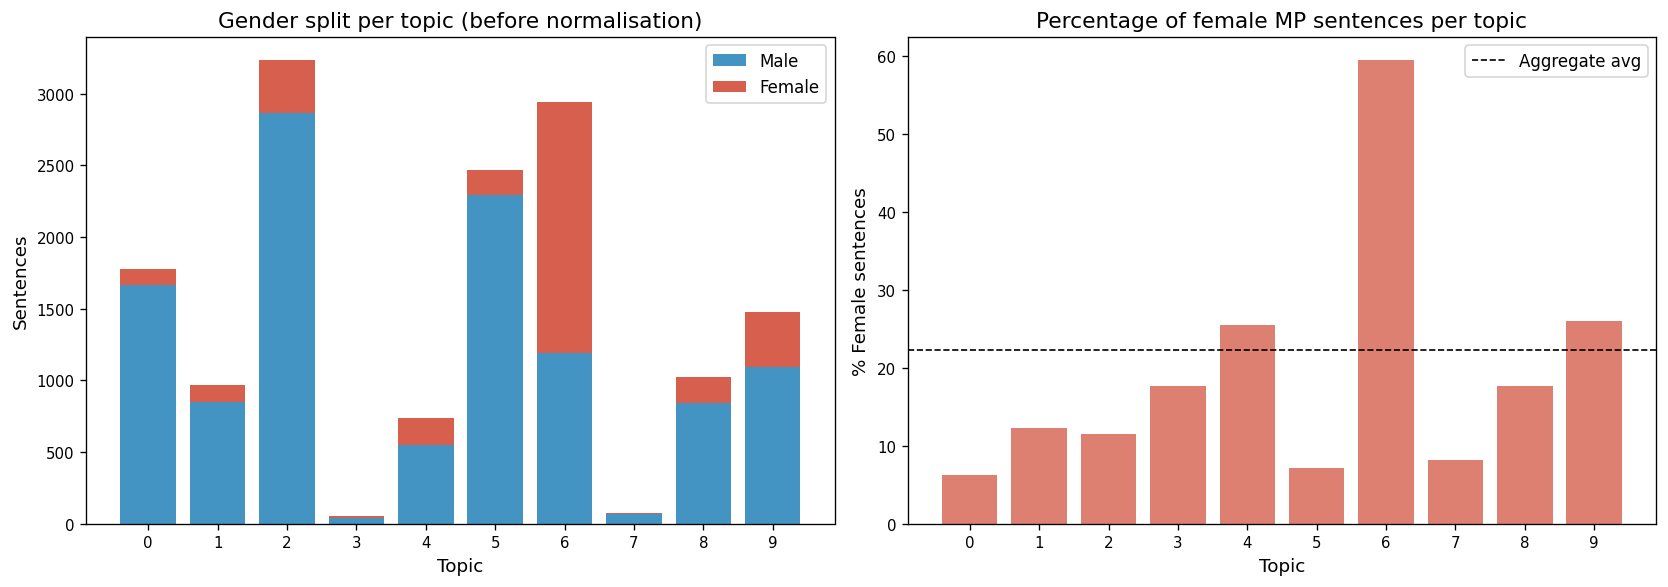

                              topic  total    M    F     pct_F  unique_MPs
     0_covid_virus_vaccine_pandemic   1777 1666  111  6.246483         112
  1_climate_emissions_carbon_energy    965  847  118 12.227979         115
   2_scottish_scotland_snp_sturgeon   3233 2862  371 11.475410         180
   3_biden_trump_sanders_democratic     51   42    9 17.647059          15
4_schools_school_education_teachers    739  551  188 25.439783          89
        5_farage_ukip_nuttall_party   2470 2293  177  7.165992         151
               6_her_she_may_brexit   2940 1193 1747 59.421769         179
              7_book_books_novel_my     73   67    6  8.219178          25
      8_nhs_health_doctors_patients   1021  841  180 17.629775          91
               9_eu_barnier_uk_deal   1473 1090  383 26.001358         114


In [6]:
# --- Per-topic: gender breakdown ---
gender_summary = []
for topic_name, tdf in sorted(topic_dfs.items()):
    gc = tdf["gender"].value_counts()
    gender_summary.append({
        "topic": topic_name,
        "total": len(tdf),
        "M": gc.get("M", 0),
        "F": gc.get("F", 0),
        "pct_F": gc.get("F", 0) / len(tdf) * 100,
        "unique_MPs": tdf["mp"].nunique(),
    })
gender_df = pd.DataFrame(gender_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: gender counts per topic
labels = [t[0] for t in gender_df["topic"]]  # topic number
x = np.arange(len(labels))
axes[0].bar(x, gender_df["M"], color="#4393c3", label="Male")
axes[0].bar(x, gender_df["F"], bottom=gender_df["M"], color="#d6604d", label="Female")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel("Topic")
axes[0].set_ylabel("Sentences")
axes[0].set_title("Gender split per topic (before normalisation)")
axes[0].legend()

# % female per topic
axes[1].bar(x, gender_df["pct_F"], color="#d6604d", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel("Topic")
axes[1].set_ylabel("% Female sentences")
axes[1].set_title("Percentage of female MP sentences per topic")
axes[1].axhline(y=df_all[df_all["gender"] == "F"].shape[0] / len(df_all) * 100,
                color="black", linestyle="--", linewidth=1, label="Aggregate avg")
axes[1].legend()

plt.tight_layout()
plt.show()

print(gender_df.to_string(index=False))

## 4. Choosing the sentence cap

The cap should be low enough to curb dominant individuals but high enough to retain statistical power. We examine several candidate thresholds.

 cap  sentences_retained  pct_retained  top10_share_pct  mps_capped
  10                2292          15.5              4.4         116
  20                3188          21.6              6.3          66
  30                3765          25.5              8.0          49
  50                4559          30.9             11.0          31
  75                5253          35.6             14.3          26
 100                5854          39.7             17.1          20
 150                6667          45.2             22.5          15
 200                7354          49.9             27.2          13


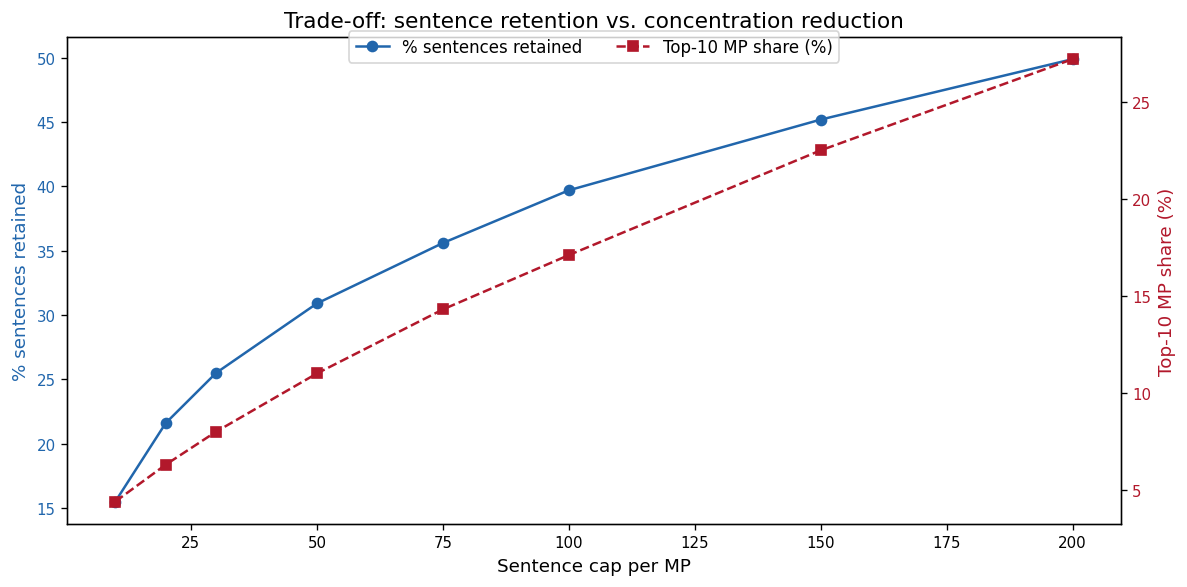

In [7]:
# --- Evaluate different cap values ---
caps = [10, 20, 30, 50, 75, 100, 150, 200]

cap_stats = []
for cap in caps:
    capped = mp_counts.copy()
    capped["capped_count"] = capped["count"].clip(upper=cap)
    total = capped["capped_count"].sum()
    retained_pct = total / mp_counts["count"].sum() * 100
    top10_share = capped.sort_values("capped_count", ascending=False).head(10)["capped_count"].sum() / total * 100
    n_affected = (mp_counts["count"] > cap).sum()
    cap_stats.append({
        "cap": cap,
        "sentences_retained": total,
        "pct_retained": round(retained_pct, 1),
        "top10_share_pct": round(top10_share, 1),
        "mps_capped": n_affected,
    })

cap_df = pd.DataFrame(cap_stats)
print(cap_df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(cap_df["cap"], cap_df["pct_retained"], "o-", color="#2166ac", label="% sentences retained")
ax1.set_xlabel("Sentence cap per MP")
ax1.set_ylabel("% sentences retained", color="#2166ac")
ax1.tick_params(axis="y", labelcolor="#2166ac")

ax2 = ax1.twinx()
ax2.plot(cap_df["cap"], cap_df["top10_share_pct"], "s--", color="#b2182b", label="Top-10 MP share (%)")
ax2.set_ylabel("Top-10 MP share (%)", color="#b2182b")
ax2.tick_params(axis="y", labelcolor="#b2182b")

fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=2)
ax1.set_title("Trade-off: sentence retention vs. concentration reduction")
plt.tight_layout()
plt.show()

## 5. Apply normalisation

Set the cap below and apply random subsampling per MP. The sampling is done **per topic** so that each topic file is normalised independently.

In [8]:
MAX_SENTENCES_PER_MP = 50  # <-- adjust this cap as needed

def normalise_topic(df, cap, seed=SEED):
    """Subsample so no MP has more than `cap` sentences."""
    rng = np.random.default_rng(seed)
    groups = []
    for mp, group in df.groupby("mp"):
        if len(group) > cap:
            idx = rng.choice(group.index, size=cap, replace=False)
            groups.append(group.loc[idx])
        else:
            groups.append(group)
    return pd.concat(groups, ignore_index=True)

# Normalise each topic independently
norm_topic_dfs = {}
for topic_name, tdf in sorted(topic_dfs.items()):
    norm_topic_dfs[topic_name] = normalise_topic(tdf, MAX_SENTENCES_PER_MP)

df_all_norm = pd.concat(norm_topic_dfs.values(), ignore_index=True)

print(f"Before: {len(df_all):,} sentences")
print(f"After:  {len(df_all_norm):,} sentences  (cap = {MAX_SENTENCES_PER_MP})")
print(f"Retained: {len(df_all_norm)/len(df_all):.1%}")
print(f"\nGender split before: {df_all['gender'].value_counts().to_dict()}")
print(f"Gender split after:  {df_all_norm['gender'].value_counts().to_dict()}")

Before: 14,742 sentences
After:  7,275 sentences  (cap = 50)
Retained: 49.3%

Gender split before: {'M': 11452, 'F': 3290}
Gender split after:  {'M': 5975, 'F': 1300}


## 6. Before vs. after comparison (aggregate)

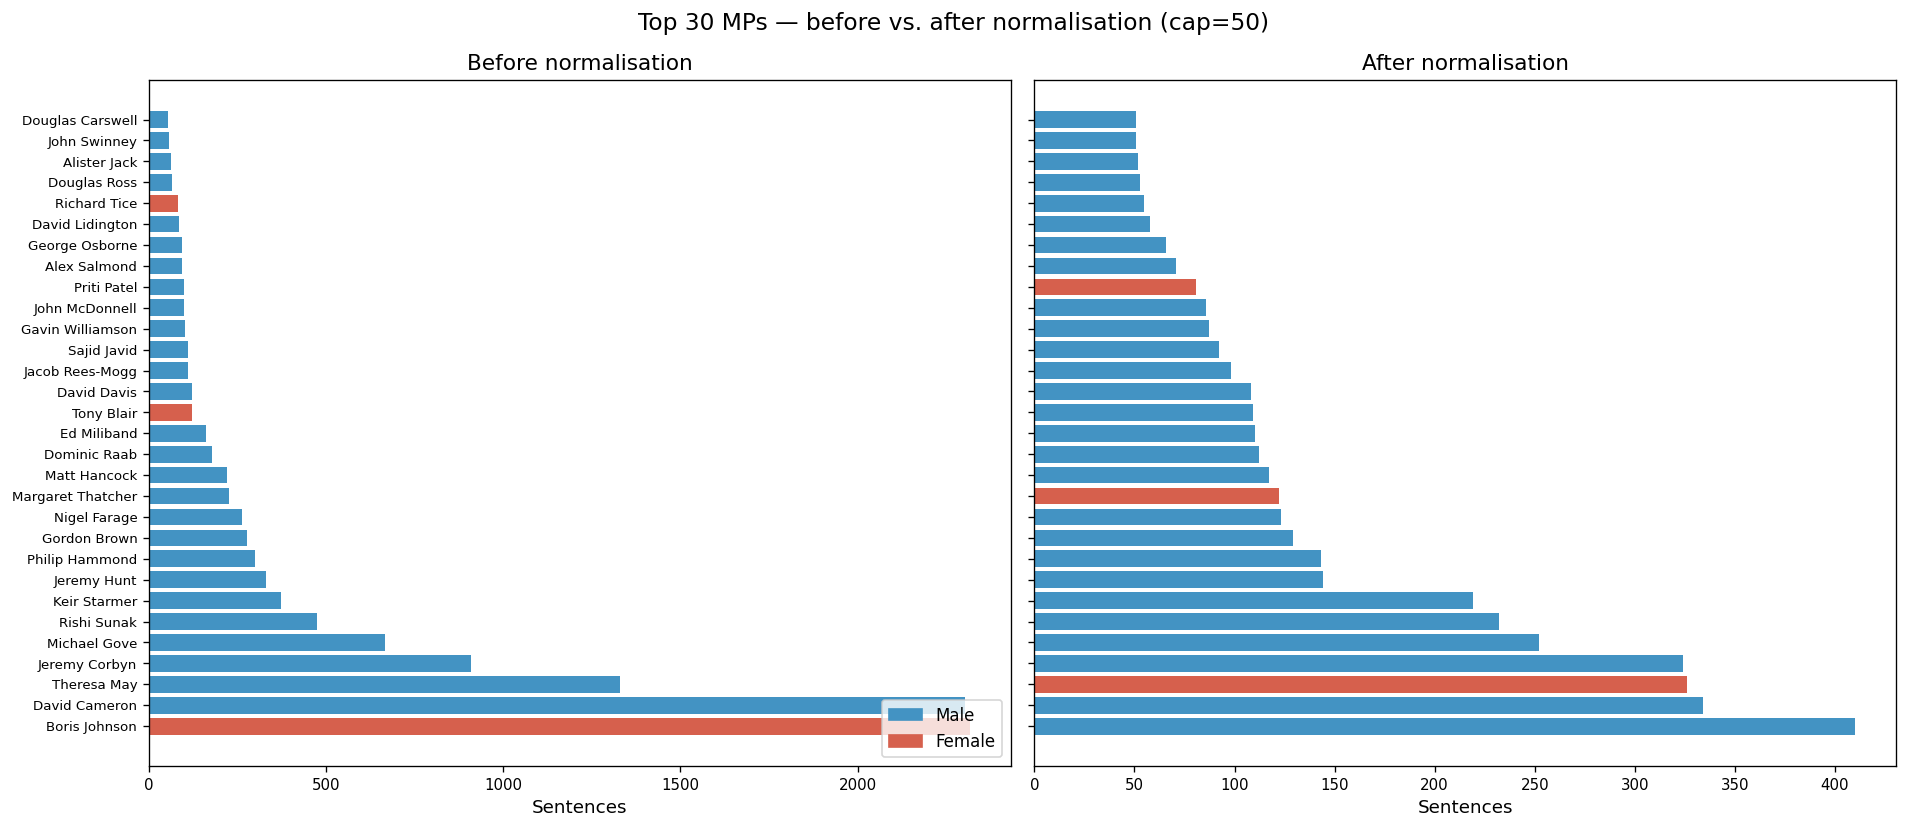

In [9]:
# --- Before vs after: top 30 MPs ---
mp_counts_norm = df_all_norm.groupby(["mp", "gender"]).size().reset_index(name="count")
mp_counts_norm = mp_counts_norm.sort_values("count", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, data, title in zip(axes,
                            [mp_counts.head(top_n), mp_counts_norm.head(top_n)],
                            ["Before normalisation", "After normalisation"]):
    colours = data["gender"].map({"M": "#4393c3", "F": "#d6604d"})
    ax.barh(range(len(data)), data["count"].values, color=colours.values)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data["mp"].values, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Sentences")
    ax.set_title(title)

axes[0].legend(handles=[Patch(color="#4393c3", label="Male"),
                        Patch(color="#d6604d", label="Female")],
               loc="lower right")
plt.suptitle(f"Top {top_n} MPs — before vs. after normalisation (cap={MAX_SENTENCES_PER_MP})", fontsize=14)
plt.tight_layout()
plt.show()

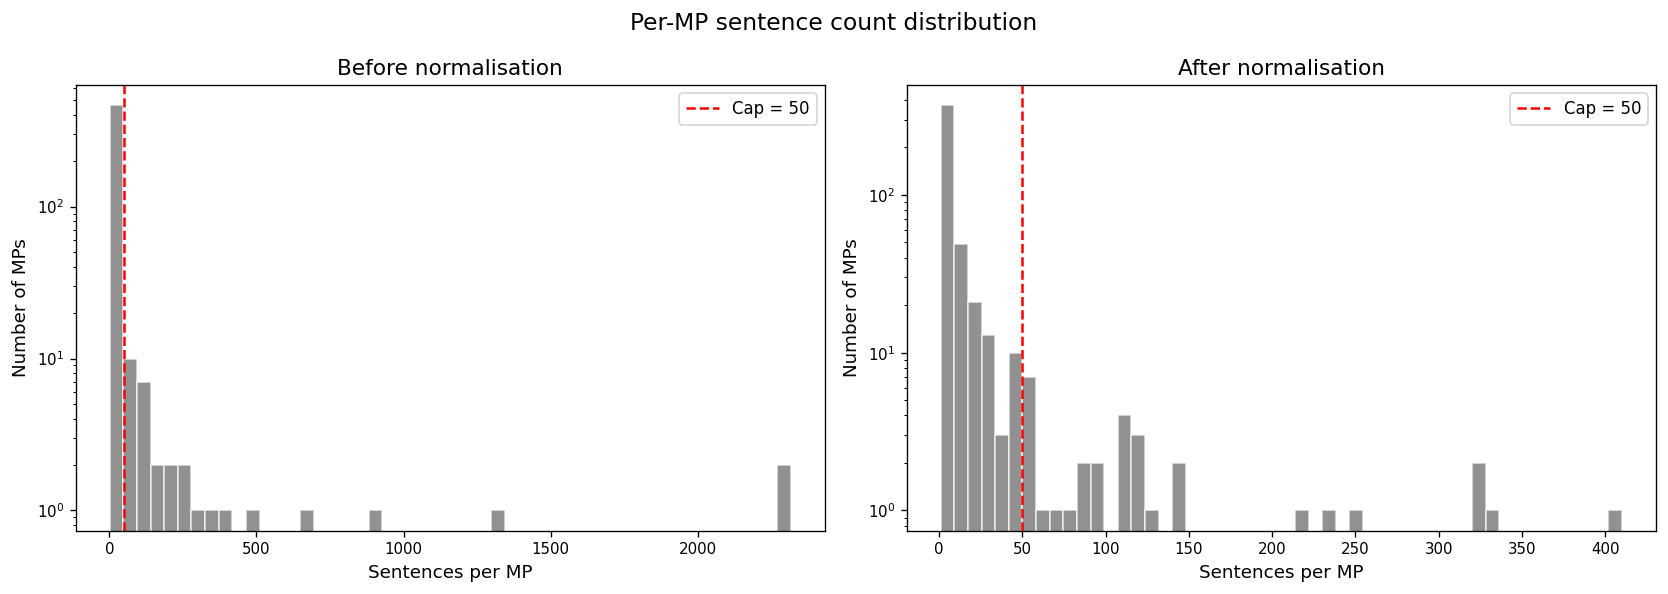

In [10]:
# --- Before vs after: distribution histograms ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(mp_counts["count"], bins=50, color="#636363", edgecolor="white", alpha=0.7)
axes[0].axvline(MAX_SENTENCES_PER_MP, color="red", linestyle="--", label=f"Cap = {MAX_SENTENCES_PER_MP}")
axes[0].set_xlabel("Sentences per MP")
axes[0].set_ylabel("Number of MPs")
axes[0].set_title("Before normalisation")
axes[0].set_yscale("log")
axes[0].legend()

axes[1].hist(mp_counts_norm["count"], bins=50, color="#636363", edgecolor="white", alpha=0.7)
axes[1].axvline(MAX_SENTENCES_PER_MP, color="red", linestyle="--", label=f"Cap = {MAX_SENTENCES_PER_MP}")
axes[1].set_xlabel("Sentences per MP")
axes[1].set_ylabel("Number of MPs")
axes[1].set_title("After normalisation")
axes[1].set_yscale("log")
axes[1].legend()

plt.suptitle("Per-MP sentence count distribution", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Before vs. after comparison (per topic)

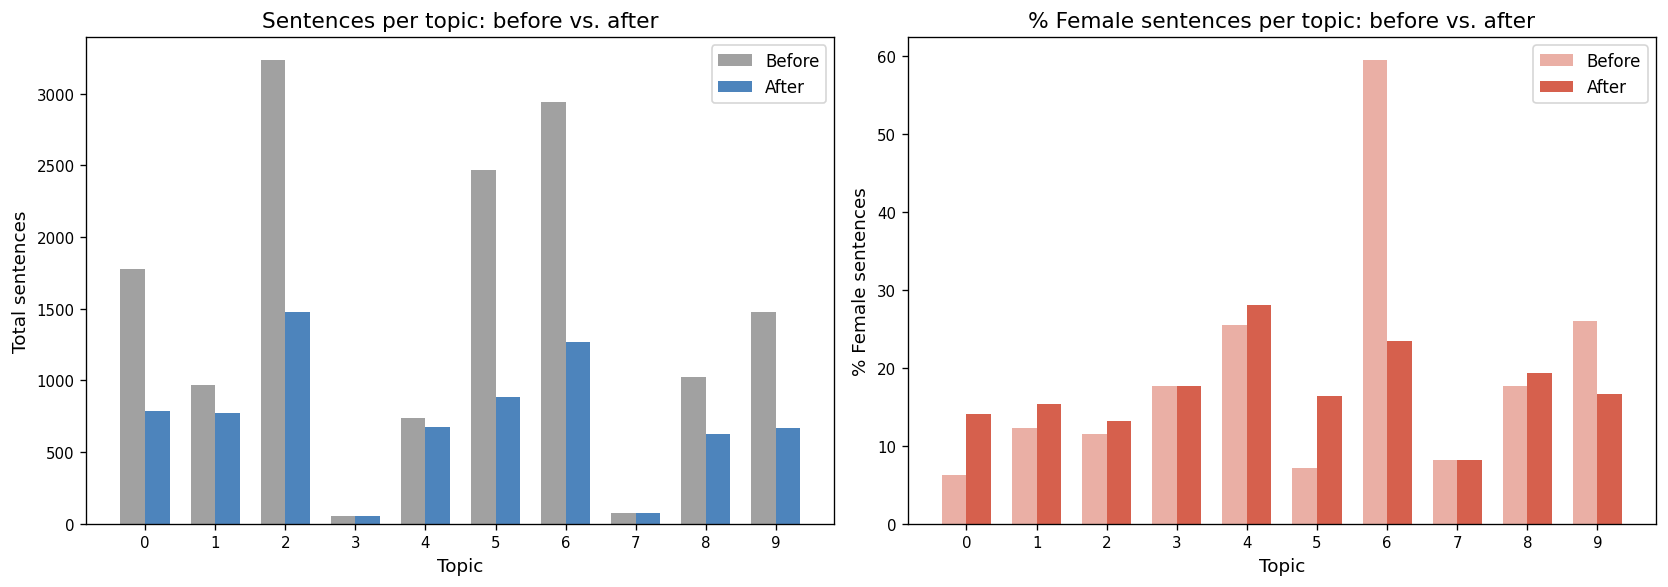

                              topic  total_before  pct_F_before  total_after  pct_F_after
     0_covid_virus_vaccine_pandemic          1777           6.2          787         14.1
  1_climate_emissions_carbon_energy           965          12.2          770         15.3
   2_scottish_scotland_snp_sturgeon          3233          11.5         1475         13.2
   3_biden_trump_sanders_democratic            51          17.6           51         17.6
4_schools_school_education_teachers           739          25.4          671         28.0
        5_farage_ukip_nuttall_party          2470           7.2          885         16.4
               6_her_she_may_brexit          2940          59.4         1268         23.4
              7_book_books_novel_my            73           8.2           73          8.2
      8_nhs_health_doctors_patients          1021          17.6          626         19.3
               9_eu_barnier_uk_deal          1473          26.0          669         16.6


In [11]:
# --- Per-topic before vs after gender comparison ---
norm_gender_summary = []
for topic_name, tdf in sorted(norm_topic_dfs.items()):
    gc = tdf["gender"].value_counts()
    norm_gender_summary.append({
        "topic": topic_name,
        "total": len(tdf),
        "M": gc.get("M", 0),
        "F": gc.get("F", 0),
        "pct_F": gc.get("F", 0) / len(tdf) * 100,
    })
norm_gender_df = pd.DataFrame(norm_gender_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [t[0] for t in gender_df["topic"]]
x = np.arange(len(labels))
w = 0.35

# Total sentences before vs after
axes[0].bar(x - w/2, gender_df["total"], w, color="#636363", alpha=0.6, label="Before")
axes[0].bar(x + w/2, norm_gender_df["total"], w, color="#2166ac", alpha=0.8, label="After")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel("Topic")
axes[0].set_ylabel("Total sentences")
axes[0].set_title("Sentences per topic: before vs. after")
axes[0].legend()

# % female before vs after
axes[1].bar(x - w/2, gender_df["pct_F"], w, color="#d6604d", alpha=0.5, label="Before")
axes[1].bar(x + w/2, norm_gender_df["pct_F"], w, color="#d6604d", alpha=1.0, label="After")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel("Topic")
axes[1].set_ylabel("% Female sentences")
axes[1].set_title("% Female sentences per topic: before vs. after")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print comparison table
comparison = gender_df[["topic", "total", "pct_F"]].merge(
    norm_gender_df[["topic", "total", "pct_F"]],
    on="topic", suffixes=("_before", "_after")
)
comparison["pct_F_before"] = comparison["pct_F_before"].round(1)
comparison["pct_F_after"] = comparison["pct_F_after"].round(1)
print(comparison.to_string(index=False))

## 8. Export normalised dataset

Saves each normalised topic file into `corpus_normalization/normalised_mp_sentences_by_topic/`.

In [12]:
OUT_DIR = Path("normalised_mp_sentences_by_topic")
OUT_DIR.mkdir(exist_ok=True)

for topic_name, tdf in sorted(norm_topic_dfs.items()):
    out_path = OUT_DIR / f"{topic_name}.csv"
    tdf.to_csv(out_path, index=False)
    print(f"  Saved {out_path}  ({len(tdf):,} rows)")

print(f"\nDone. {len(norm_topic_dfs)} normalised topic files written to {OUT_DIR}/")
print(f"Total normalised sentences: {len(df_all_norm):,}")

  Saved normalised_mp_sentences_by_topic/0_covid_virus_vaccine_pandemic.csv  (787 rows)
  Saved normalised_mp_sentences_by_topic/1_climate_emissions_carbon_energy.csv  (770 rows)
  Saved normalised_mp_sentences_by_topic/2_scottish_scotland_snp_sturgeon.csv  (1,475 rows)
  Saved normalised_mp_sentences_by_topic/3_biden_trump_sanders_democratic.csv  (51 rows)
  Saved normalised_mp_sentences_by_topic/4_schools_school_education_teachers.csv  (671 rows)
  Saved normalised_mp_sentences_by_topic/5_farage_ukip_nuttall_party.csv  (885 rows)
  Saved normalised_mp_sentences_by_topic/6_her_she_may_brexit.csv  (1,268 rows)
  Saved normalised_mp_sentences_by_topic/7_book_books_novel_my.csv  (73 rows)
  Saved normalised_mp_sentences_by_topic/8_nhs_health_doctors_patients.csv  (626 rows)
  Saved normalised_mp_sentences_by_topic/9_eu_barnier_uk_deal.csv  (669 rows)

Done. 10 normalised topic files written to normalised_mp_sentences_by_topic/
Total normalised sentences: 7,275
